In [18]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import hypernetx as hnx
from IPython.display import display

In [19]:
data = pd.read_stata('rete_IPL.dta')
data['anno'] = data['anno'].astype(int)
data['codfisc'] = data['codfisc'].astype(int)
data['codfisc_ente'] = data['codfisc_ente'].astype(int)

In [ ]:
filtered_data = data[data['anno'] == 2020]

H = hnx.Hypergraph(
    filtered_data,
    edge_col="codfisc",
    node_col="codfisc_ente",
    cell_weight_col="quota_totale_ente"
)

In [21]:
edges_subset = filtered_data['codfisc'].unique()[:200]

H_sub = H.restrict_to_edges(edges_subset)

In [22]:
for edge in H_sub.edges:
    if len(H_sub.edges[edge]) > 100:
        print(f"Partecipata: {edge}, Comuni: {len(H_sub.edges[edge])}")

Partecipata: 756180527, Comuni: 125
Partecipata: 1246510190, Comuni: 174
Partecipata: 1495500520, Comuni: 179
Partecipata: 1994700225, Comuni: 121
Partecipata: 2053450769, Comuni: 116
Partecipata: 2350830390, Comuni: 174
Partecipata: 2382470223, Comuni: 174
Partecipata: 2497930285, Comuni: 117
Partecipata: 2588010229, Comuni: 121
Partecipata: 2602460228, Comuni: 117
Partecipata: 3609451202, Comuni: 121
Partecipata: 3757240548, Comuni: 179


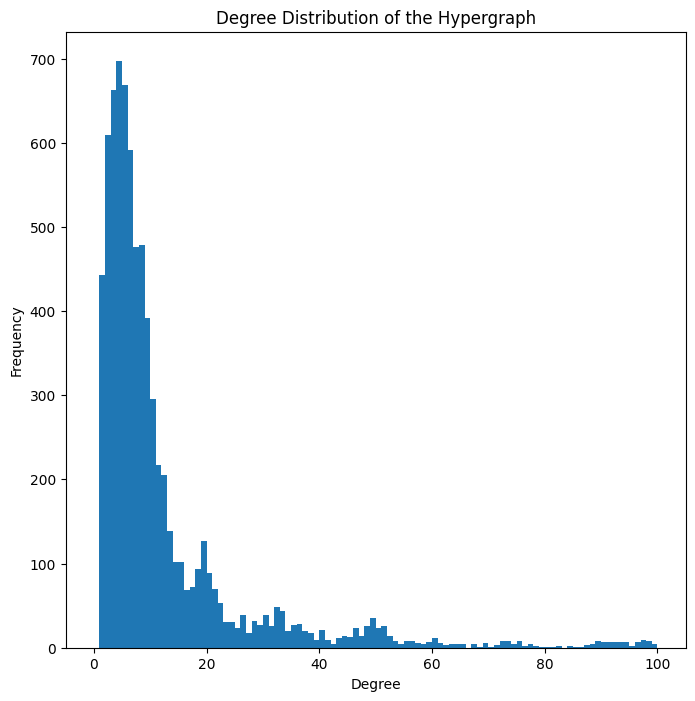

In [23]:
distribution = {node: H.degree(node) for node in H.nodes}
plt.hist(list(distribution.values()), bins=100, range=(0,100))
plt.title('Degree Distribution of the Hypergraph')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Statistics

In [7]:
yearly_groups = {
    int(year): frame.copy()
    for year, frame in data.groupby('anno', sort=True)
}

hypergraphs_by_year = {
    year: hnx.Hypergraph(
        frame.drop_duplicates(subset=['codfisc', 'codfisc_ente']),
        edge_col='codfisc',
        node_col='codfisc_ente',
        cell_weight_col='quota_totale_ente'
    )
    for year, frame in yearly_groups.items()
}

def compute_yearly_hypergraph_stats(year, frame):
    incidence = frame[['codfisc', 'codfisc_ente']].drop_duplicates()
    edge_sizes = incidence.groupby('codfisc')['codfisc_ente'].nunique()
    node_degrees = incidence.groupby('codfisc_ente')['codfisc'].nunique()

    bipartite = nx.Graph()
    bipartite.add_nodes_from((
        f'edge_{edge}', {'bipartite': 'edge'}
    ) for edge in edge_sizes.index)
    bipartite.add_nodes_from((
        f'node_{node}', {'bipartite': 'node'}
    ) for node in node_degrees.index)
    bipartite.add_edges_from(
        (f"edge_{row.codfisc}", f"node_{row.codfisc_ente}")
        for row in incidence.itertuples(index=False)
    )

    component_sizes = sorted(
        (len(component) for component in nx.connected_components(bipartite)),
        reverse=True
    )
    total_vertices = bipartite.number_of_nodes()

    return pd.Series({
        'year': year,
        'records': len(frame),
        'incidences': len(incidence),
        'hyperedges': edge_sizes.size,
        'nodes': node_degrees.size,
        'avg_edge_size': edge_sizes.mean(),
        'median_edge_size': edge_sizes.median(),
        'max_edge_size': edge_sizes.max(),
        'avg_node_degree': node_degrees.mean(),
        'median_node_degree': node_degrees.median(),
        'max_node_degree': node_degrees.max(),
        'connected_components': len(component_sizes),
        'largest_component_share': (
            component_sizes[0] / total_vertices if total_vertices else np.nan
        ),
        'total_weight': frame['quota_totale_ente'].sum(),
        'avg_weight_per_incidence': frame['quota_totale_ente'].mean()
    })

yearly_stats = pd.DataFrame(
    compute_yearly_hypergraph_stats(year, frame)
    for year, frame in yearly_groups.items()
).sort_values('year').reset_index(drop=True)

yearly_stats

,year,records,incidences,hyperedges,nodes,avg_edge_size,median_edge_size,max_edge_size,avg_node_degree,median_node_degree,max_node_degree,connected_components,largest_component_share,total_weight,avg_weight_per_incidence
0,2009.0,14.0,14.0,6.0,12.0,2.333333,2.5,3.0,1.166667,1.0,2.0,5.0,0.277778,164.10556,11.721826
1,2010.0,172510.0,172510.0,7105.0,7677.0,24.280084,3.0,416.0,22.471017,5.0,605.0,54.0,0.991273,312375.46875,1.810767
2,2011.0,170540.0,170540.0,12504.0,7766.0,13.638836,3.0,431.0,21.959825,7.0,3305.0,31.0,0.995017,360327.25000,2.112861
3,2012.0,241227.0,241227.0,12664.0,7806.0,19.048247,2.0,500.0,30.902767,7.0,2556.0,25.0,0.996922,362824.43750,1.504079
4,2013.0,253409.0,253409.0,12478.0,7818.0,20.308463,3.0,601.0,32.413533,8.0,3661.0,26.0,0.997192,358220.21875,1.413605
5,2014.0,248888.0,248888.0,12239.0,7856.0,20.335648,3.0,622.0,31.681263,7.0,3151.0,24.0,0.997363,362682.18750,1.457210
6,2015.0,255244.0,255244.0,12558.0,7880.0,20.325211,5.0,604.0,32.391371,8.0,3519.0,23.0,0.997456,367590.71875,1.440154
7,2016.0,165359.0,165359.0,14005.0,7844.0,11.807140,1.0,503.0,21.080954,8.0,2939.0,19.0,0.998261,356061.06250,2.153261
8,2017.0,141602.0,141602.0,8356.0,7827.0,16.946146,2.0,696.0,18.091478,7.0,850.0,17.0,0.997775,341299.93750,2.410276
9,2018.0,138117.0,138117.0,8114.0,7797.0,17.022061,2.0,818.0,17.714121,7.0,818.0,17.0,0.997800,334247.37500,2.420031


In [8]:
selected_year = int(yearly_stats.loc[yearly_stats['max_edge_size'].idxmax(), 'year'])
selected_frame = yearly_groups[selected_year]
selected_incidence = selected_frame[['codfisc', 'codfisc_ente']].drop_duplicates()

largest_hyperedges = (
    selected_incidence.groupby('codfisc')['codfisc_ente']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .rename('edge_size')
    .reset_index()
    .rename(columns={'codfisc': 'hyperedge'})
)

highest_degree_nodes = (
    selected_incidence.groupby('codfisc_ente')['codfisc']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .rename('degree')
    .reset_index()
    .rename(columns={'codfisc_ente': 'node'})
)

print(f'Selected year: {selected_year}')
print('Top 10 largest hyperedges')
display(largest_hyperedges)
print('Top 10 highest-degree nodes')
display(highest_degree_nodes)

Selected year: 2021
Top 10 largest hyperedges


,hyperedge,edge_size
0,9613941211,834
1,12236141003,829
2,5166621218,567
3,4042120230,540
4,4633850484,510
5,2230170025,414
6,2344270356,397
7,6111950488,395
8,2134230206,361
9,2934390929,333


Top 10 highest-degree nodes


,node,degree
0,168650307,594
1,1252100480,525
2,82000250504,524
3,516890241,516
4,1307110484,493
5,218770394,391
6,226010395,390
7,761890177,371
8,80004590677,312
9,2253930156,310


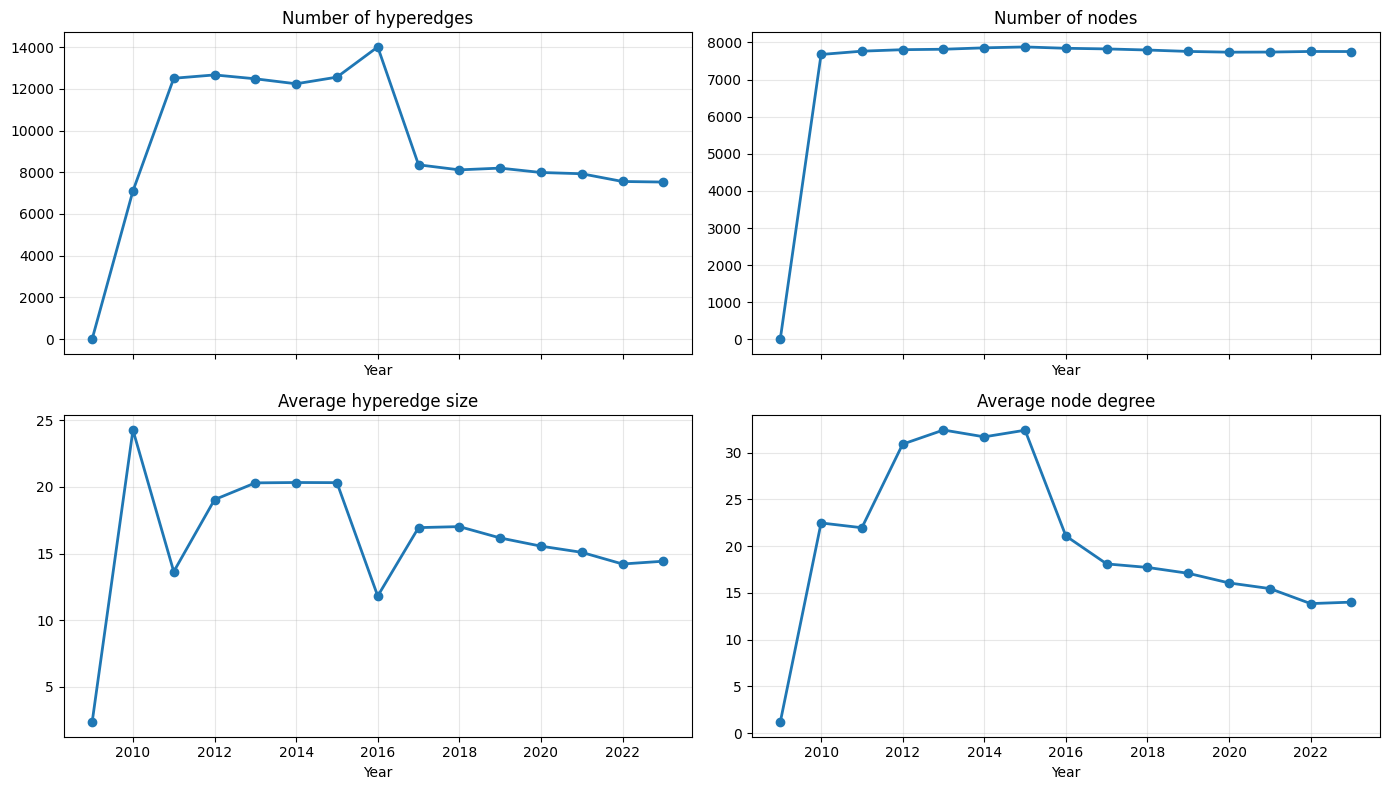

In [9]:
metrics_to_plot = [
    ('hyperedges', 'Number of hyperedges'),
    ('nodes', 'Number of nodes'),
    ('avg_edge_size', 'Average hyperedge size'),
    ('avg_node_degree', 'Average node degree')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
    ax.plot(yearly_stats['year'], yearly_stats[metric], marker='o', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Data cleaning

In [29]:
column_rename_map = {
    'codfisc': 'CF Partecipata',
    'codfisc_ente': 'CF Comune',
    'denominazione_ente': 'Comune',
    'quota_totale_ente': 'Quota'
}

columns_in_order = [
    'codfisc_ente',
    'denominazione_ente',
    'codfisc',
    'quota_totale_ente'
 ]

df_per_year = {
    int(year): (
        frame[columns_in_order]
        .rename(columns=column_rename_map)
        .reset_index(drop=True)
    )
    for year, frame in data.groupby('anno', sort=True)
    if int(year) != 2009
}

df_per_year[next(iter(df_per_year))]

,CF Comune,Comune,CF Partecipata,Quota
0,210240321,COMUNE DI TRIESTE,28470326,25.500000
1,101880078,COMUNE DI BRISSOGNE,40450074,1.195932
2,68560911,COMUNE DI TORTOLI',42010959,0.166667
3,102860079,COMUNE DI COGNE,48470074,51.000000
4,114700149,COMUNE DI VALFURVA,57010142,1.343552
...,...,...,...,...
172505,377510177,COMUNE DI PISOGNE,98002670176,5.400000
172506,80015590179,COMUNE DI ZONE,98002670176,1.260000
172507,80013870169,COMUNE DI SARNICO,98002670176,3.210000
172508,813320173,COMUNE DI PROVAGLIO D'ISEO,98002670176,2.940000


In [34]:
all_cf_comuni = set().union(*(set(df['CF Comune'].unique()) for df in df_per_year.values()))

coverage_rows = []
for year, df in sorted(df_per_year.items()):
    comuni_in_year = set(df['CF Comune'].unique())
    missing_comuni = all_cf_comuni - comuni_in_year
    coverage_rows.append({
        'year': year,
        'unique_CF_Comune_in_year': len(comuni_in_year),
        'total_unique_CF_Comune': len(all_cf_comuni),
        'coverage_pct': 100 * len(comuni_in_year) / len(all_cf_comuni),
        'contains_all_comuni': len(missing_comuni) == 0,
        'missing_comuni_count': len(missing_comuni)
    })

coverage_by_year = pd.DataFrame(coverage_rows)
display(coverage_by_year)

common_cf_comuni = set.intersection(*(set(df['CF Comune'].unique()) for df in df_per_year.values()))
common_cf_comuni_df = pd.DataFrame({'CF Comune': sorted(common_cf_comuni)})

print(f'CF Comune present in every year: {len(common_cf_comuni)}')
common_cf_comuni_df.head(20)

,year,unique_CF_Comune_in_year,total_unique_CF_Comune,coverage_pct,contains_all_comuni,missing_comuni_count
0,2010,7677,8149,94.207878,False,472
1,2011,7766,8149,95.300037,False,383
2,2012,7806,8149,95.790895,False,343
3,2013,7818,8149,95.938152,False,331
4,2014,7856,8149,96.404467,False,293
5,2015,7880,8149,96.698981,False,269
6,2016,7844,8149,96.257209,False,305
7,2017,7827,8149,96.048595,False,322
8,2018,7797,8149,95.680452,False,352
9,2019,7759,8149,95.214137,False,390


CF Comune present in every year: 7277


,CF Comune
0,8010803
1,31500945
2,31730948
3,33120437
4,34670943
5,38870945
6,43820620
7,46540860
8,46840864
9,50800523


In [35]:
for year, df in df_per_year.items():
    df_sorted = df.sort_values('CF Comune').reset_index(drop=True)
    filename = f'rete_{year}.csv'
    df_sorted.to_csv(filename, index=False)
    print(f'Saved {filename} with {len(df_sorted)} rows')

print('All yearly DataFrames saved as CSV files.')

Saved rete_2010.csv with 172510 rows
Saved rete_2011.csv with 170540 rows
Saved rete_2012.csv with 241227 rows
Saved rete_2013.csv with 253409 rows
Saved rete_2014.csv with 248888 rows
Saved rete_2015.csv with 255244 rows
Saved rete_2016.csv with 165359 rows
Saved rete_2017.csv with 141602 rows
Saved rete_2018.csv with 138117 rows
Saved rete_2019.csv with 132564 rows
Saved rete_2020.csv with 124248 rows
Saved rete_2021.csv with 119628 rows
Saved rete_2022.csv with 107405 rows
Saved rete_2023.csv with 108598 rows
All yearly DataFrames saved as CSV files.
